<a href="https://colab.research.google.com/github/Hugo-Mendonca/Teste-Voxar/blob/main/Teste_t%C3%A9cnico_Voxar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Teste técnico da Voxar(Visão Computacional)

##Apresentação do problema

O problema referido se trata de um problema de natureza classificatoria, o dataset trata de tipos de estrada tendo 3 classes(Asphalt, belgian_blocks e offroad) e temos como objetivo criar um modelo para que ele consiga ler uma imagem e classifique o tipo de estrada em um desses 3 tipos. Para quais finalidades isso pode ser útil:

1- Adaptação de coportamento de carros Autonomos:

Poderiamos usar isso para que carro autonomos consigam identificar o tipo da estrada e com isso possaaa usar a configuração do carro que melhor se adeque para o tipo da estrada, por exemplo se Se o sistema detecta que a estrada é offroad, ele deve ajustar o controle de tração, a sensibilidade da frenagem (evitar travar as rodas em terreno irregular), afim de evitar problemas.

2-Otimização de roteamento:

Isso é um ótima funcionalidades para aplicativos de gps como waze ou google maps, visto que o roteador pode sugerir uma rota 2km mais longa, mas que seja 100% asfaltada de maneira a otimizar o tempo do usuário.

3-Inventário de Ativos:

Muitas prefeitura(especialmente nos interiores) não tem um mapa atualizado de quais ruas são asfaltadas ou não, ou seja, uma solução proposta seria que os caminhões de lixo(detém a maior cobertura da cidade) sejam equipados com essa tecnologia afim de auxiliar a prefeitura a identificar as ruas que precisam ser asfaltadas.

##Estudo sobre o Dataset


In [4]:
from google.colab import files
import os
from PIL import Image
import random

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.metrics import classification_report

from tqdm import tqdm

###Análise Exploratória dos Dados (EDA)


#### 1. Fazer Upload do Arquivo .zip



In [ ]:

print("Por favor, selecione o arquivo .zip do seu dataset para upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print('Arquivo "{name}" com tamanho {length} bytes foi carregado com sucesso.'.format(
      name=fn, length=len(uploaded[fn])))


Por favor, selecione o arquivo .zip do seu dataset para upload:


#### 2. Descompactar o Dataset

Agora, vamos descompactar o arquivo `.zip`. Certifique-se de substituir `nome_do_seu_dataset.zip` pelo nome real do arquivo que você carregou. Eu assumirei que o nome do arquivo .zip é o primeiro arquivo carregado.

In [ ]:
zip_file_name = list(uploaded.keys())[0]

# Criar uma pasta para o dataset descompactado
# O nome da pasta será o nome do arquivo zip (sem a extensão .zip)
dataset_name = os.path.splitext(zip_file_name)[0]
if not os.path.exists(dataset_name):
    os.makedirs(dataset_name)

# Descompactar o arquivo
!unzip -q "{zip_file_name}" -d "{dataset_name}"

print(f"Dataset '{zip_file_name}' descompactado para a pasta '{dataset_name}'.")
print("Verificando a estrutura de pastas:")
!ls -R "{dataset_name}" # Lista recursivamente o conteúdo da pasta


#### 3.1 Análise Geométrica das Imagens Originais

Antes de aplicar quaisquer transformações, vamos analisar as dimensões originais das imagens no dataset para entender a distribuição de largura, altura e proporção. Isso nos ajudará a tomar decisões informadas sobre as transformações de `resize` e `crop`.

In [ ]:
#Função para coletar as dimensões das nossas imagens.
def collect_image_dimensions(base_dir):
    widths = []
    heights = []
    aspect_ratios = []
    image_paths = []
    type_file = []

    # percorre pecorrer dentro das pastas para achar todas as imagens
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                image_paths.append(os.path.join(root, file))

    print(f"Coletando dimensões para {len(image_paths)} imagens em {base_dir}...")

    for img_path in image_paths:
        try:
            with Image.open(img_path) as img:
                image_type = img.format
                type_file.append(image_type)
                width, height = img.size
                widths.append(width)
                heights.append(height)
                aspect_ratios.append(width / height)
        except Exception as e:
            print(f"Não foi possível abrir ou processar a imagem {img_path}: {e}")

    return widths, heights, aspect_ratios, type_file

# Define o caminho para as pastas de treino e teste dentro do dataset descompactado
# As variáveis dataset_name já estão definidas do passo anterior.
train_dir_full_path = os.path.join(dataset_name, 'dataset_processed', 'train') # Adjusting path based on 'ls -R' output
test_dir_full_path = os.path.join(dataset_name, 'dataset_processed', 'test') # Adjusting path based on 'ls -R' output

# Coleta as dimensões do dataset de treino
train_widths, train_heights, train_aspect_ratios,train_file_type = collect_image_dimensions(train_dir_full_path)

# Coleta as dimensões do dataset de teste
test_widths, test_heights, test_aspect_ratios, test_file_type = collect_image_dimensions(test_dir_full_path)

#Criando um dicionário para dizer quais tipos de arquivo temos no dataset(png,jpeg,etc)
unique_targets_file, counts_file_type = np.unique(train_file_type, return_counts=True)
class_counts_file_type = dict(zip(unique_targets_file, counts_file_type))

print("Contagem de tipos de arquivo de imagem no dataset de treino:")
for class_name_file_type, count in class_counts_file_type.items():
    print(f"  {class_name_file_type} apareceu: {count} vezes")

# Combina as dimensões para uma análise geral
all_widths = train_widths + test_widths
all_heights = train_heights + test_heights
all_aspect_ratios = train_aspect_ratios + test_aspect_ratios

print(f"\nTotal de imagens analisadas: {len(all_widths)}")
print("Estatísticas de Largura:")
print(f"  Mínima: {np.min(all_widths)}, Máxima: {np.max(all_widths)}, Média: {np.mean(all_widths):.2f}, Mediana: {np.median(all_widths)}")
print("Estatísticas de Altura:")
print(f"  Mínima: {np.min(all_heights)}, Máxima: {np.max(all_heights)}, Média: {np.mean(all_heights):.2f}, Mediana: {np.median(all_heights)}")
print("Estatísticas de Proporção (Largura/Altura):")
print(f"  Mínima: {np.min(all_aspect_ratios):.2f}, Máxima: {np.max(all_aspect_ratios):.2f}, Média: {np.mean(all_aspect_ratios):.2f}, Mediana: {np.median(all_aspect_ratios):.2f}")

In [ ]:
# Plota histogramas para Largura e Altura
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
sns.histplot(all_widths, bins=30, kde=True)
plt.title('Distribuição das Larguras das Imagens Originais')
plt.xlabel('Largura (pixels)')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
sns.histplot(all_heights, bins=30, kde=True)
plt.title('Distribuição das Alturas das Imagens Originais')
plt.xlabel('Altura (pixels)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

In [ ]:
# Plota histograma para a Proporção (Aspect Ratio)
plt.figure(figsize=(8, 6))
sns.histplot(all_aspect_ratios, bins=30, kde=True)
plt.title('Distribuição da Proporção das Imagens Originais (Largura/Altura)')
plt.xlabel('Proporção (Aspect Ratio)')
plt.ylabel('Frequência')
plt.show()

# Análise das categorias de proporção
vertical_count = sum(1 for ar in all_aspect_ratios if ar < 0.9)
square_count = sum(1 for ar in all_aspect_ratios if 0.9 <= ar <= 1.1)
horizontal_count = sum(1 for ar in all_aspect_ratios if ar > 1.1)

total_images = len(all_aspect_ratios)

print("\nClassificação por Proporção:")
print(f"  Imagens Verticais (Largura/Altura < 0.9): {vertical_count} ({vertical_count/total_images:.2%})")
print(f"  Imagens Quadradas (0.9 <= Largura/Altura <= 1.1): {square_count} ({square_count/total_images:.2%})")
print(f"  Imagens Horizontais (Largura/Altura > 1.1): {horizontal_count} ({horizontal_count/total_images:.2%})")

In [ ]:
#Gráfico de Pizza para ve quais os tipos de arquivos estamos lidando.
plt.figure(figsize=(6,6))
plt.pie(class_counts_file_type.values(), labels=class_counts_file_type.keys(), autopct='%1.1f%%')
plt.title('Distribuição das Classes no Dataset de Treino')
plt.show()

#### 3. Carregar o Dataset Usando `torchvision.datasets.ImageFolder`

Vamos definir as transformações e carregar os datasets de treino e teste.

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((384, 384)), # Redimensiona todas as imagens para 384x384 para reter mais detalhes
    transforms.RandomHorizontalFlip(), # Aumenta o dataset horizontalmente
    transforms.ToTensor(), # Converte a imagem para um tensor PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normaliza
])

transform_test = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Carrega os datasets usando ImageFolder
try:
    train_dataset = datasets.ImageFolder(train_dir_full_path, transform=transform_train)
    test_dataset = datasets.ImageFolder(test_dir_full_path, transform=transform_test)

    print(f"Número de imagens de treino: {len(train_dataset)}")
    print(f"Número de imagens de teste: {len(test_dataset)}")
    print(f"Classes encontradas: {train_dataset.classes}")

    # Cria DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"\nPrimeiro batch do DataLoader de treino: {next(iter(train_loader))[0].shape}")

except Exception as e:
    print(f"Erro ao carregar o dataset com ImageFolder: {e}")
    print("Verifique se a estrutura de pastas está correta (ex: seu_dataset/dataset_processed/train/classe1/img.jpg).")
    print("Caminho do diretório de treino esperado:", train_dir_full_path)
    print("Caminho do diretório de teste esperado:", test_dir_full_path)

In [ ]:
# Obter os nomes das classes e transforma-las em valores numéricos para contagem
class_names = train_dataset.classes
class_targets = train_dataset.targets

# Contar o número de ocorrências de cada classe
unique_targets, counts = np.unique(class_targets, return_counts=True)
class_counts = dict(zip([class_names[t] for t in unique_targets], counts))

print("Contagem de imagens por classe no dataset de treino:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} imagens")

In [ ]:
#Criação de um gráfico para melhor vizualização das distribuições das classes
plt.figure(figsize=(6,6))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
plt.title('Distribuição das Classes no Dataset de Treino')
plt.show()


#### 3.2 Análise de Cores, Brilho e Contraste das Imagens

In [ ]:
# Função para calcular métricas de cor, brilho, contraste e dimensões de uma imagem
def calculate_image_metrics(image_path):
    try:
        with Image.open(image_path) as img:
            image_type = img.format
            width, height = img.size

            # Converter para RGB (se não for) e depois para array NumPy
            img_rgb = img.convert('RGB')
            img_np = np.array(img_rgb)

            # Calcular brilho médio (luminosidade): média dos valores de pixels em todos os canais
            brightness = np.mean(img_np)

            # Calcular contraste: desvio padrão dos valores de pixels em todos os canais
            contrast = np.std(img_np)

            # Calcular valores médios dos canais R, G, B
            mean_r = np.mean(img_np[:, :, 0])
            mean_g = np.mean(img_np[:, :, 1])
            mean_b = np.mean(img_np[:, :, 2])

            return brightness, contrast, mean_r, mean_g, mean_b, width, height

    except Exception as e:
        print(f"Erro ao processar a imagem {image_path}: {e}")
        return None, None, None, None, None, None, None

# Coletar dados para todas as imagens no conjunto de treino
image_metrics_data = []
# 'train_dataset.samples' contém tuplas (caminho_da_imagem, indice_da_classe)
for img_path, class_idx in tqdm(train_dataset.samples, desc="Processando imagens de treino para métricas"):
    brightness, contrast, mean_r, mean_g, mean_b, width, height = calculate_image_metrics(img_path)
    if brightness is not None:
        image_metrics_data.append({
            'path': img_path,
            'class': class_names[class_idx], # Usa os nomes das classes definidos anteriormente
            'brightness': brightness,
            'contrast': contrast,
            'mean_r': mean_r,
            'mean_g': mean_g,
            'mean_b': mean_b,
            'width': width,
            'height': height
        })

# Criar um DataFrame com as métricas coletadas
metrics_df = pd.DataFrame(image_metrics_data)

print("Métricas de imagem coletadas com sucesso.")
display(metrics_df.head())

#### 3.2.1 Distribuição de Brilho por Classe

In [ ]:
# Plotar a Distribuição de Brilho
plt.figure(figsize=(10, 6))
sns.histplot(data=metrics_df, x='brightness', hue='class', kde=True, palette='viridis')
plt.title('Distribuição de Brilho da Imagem por Classe (Conjunto de Treino)')
plt.xlabel('Brilho Médio (0-255)')
plt.ylabel('Frequência')
plt.show()

#### 3.2.2 Distribuição de Contraste por Classe

In [ ]:
# Plotar a Distribuição de Contraste
plt.figure(figsize=(10, 6))
sns.histplot(data=metrics_df, x='contrast', hue='class', kde=True, palette='magma')
plt.title('Distribuição de Contraste da Imagem por Classe (Conjunto de Treino)')
plt.xlabel('Desvio Padrão da Intensidade de Pixel (Contraste)')
plt.ylabel('Frequência')
plt.show()

#### 3.2.3 Distribuição dos Canais de Cor (RGB) por Classe

In [ ]:
# Plotar a Distribuição dos valores médios de RGB
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=metrics_df, x='mean_r', hue='class', kde=True, palette='Reds')
plt.title('Intensidade Média do Canal Vermelho')
plt.xlabel('Média da Intensidade Vermelha')
plt.ylabel('Frequência')

plt.subplot(1, 3, 2)
sns.histplot(data=metrics_df, x='mean_g', hue='class', kde=True, palette='Greens')
plt.title('Intensidade Média do Canal Verde')
plt.xlabel('Média da Intensidade Verde')
plt.ylabel('Frequência')

plt.subplot(1, 3, 3)
sns.histplot(data=metrics_df, x='mean_b', hue='class', kde=True, palette='Blues')
plt.title('Intensidade Média do Canal Azul')
plt.xlabel('Média da Intensidade Azul')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

#### 3.3 Visualização de Amostras de Imagens por Classe

In [ ]:
#Função para dispor as imagens em um grid
def display_image_grid(image_paths, title, rows, cols):
    plt.figure(figsize=(cols * 4, rows * 4))
    plt.suptitle(title, fontsize=16)
    for i, img_path in enumerate(image_paths):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Coletar 5 amostras aleatórias de cada classe
samples_per_class = 5
images_to_display = []

for class_name in class_names:
    class_df = metrics_df[metrics_df['class'] == class_name]
    #Garantir que não tentemos amostrar mais imagens do que as disponíveis
    num_samples = min(samples_per_class, len(class_df))
    if num_samples > 0:
        sample_paths = random.sample(class_df['path'].tolist(), num_samples)
        images_to_display.extend(sample_paths)

display_image_grid(images_to_display, '5 Amostras Aleatórias por Classe', len(class_names), samples_per_class)

#### 3.4 Visualização de Imagens com Resoluções Extremas

In [ ]:
# Imagens com maior e menor largura
min_width_img_path = metrics_df.loc[metrics_df['width'].idxmin()]['path']
max_width_img_path = metrics_df.loc[metrics_df['width'].idxmax()]['path']

# Imagens com maior e menor altura
min_height_img_path = metrics_df.loc[metrics_df['height'].idxmin()]['path']
max_height_img_path = metrics_df.loc[metrics_df['height'].idxmax()]['path']

extreme_resolution_paths = [
    min_width_img_path, max_width_img_path,
    min_height_img_path, max_height_img_path
]

extreme_resolution_titles = [
    f"Menor Largura ({metrics_df['width'].min()}px)",
    f"Maior Largura ({metrics_df['width'].max()}px)",
    f"Menor Altura ({metrics_df['height'].min()}px)",
    f"Maior Altura ({metrics_df['height'].max()}px)"
]

plt.figure(figsize=(15, 8))
plt.suptitle('Imagens com Resoluções Extremas', fontsize=16)

for i, img_path in enumerate(extreme_resolution_paths):
    plt.subplot(2, 2, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"{extreme_resolution_titles[i]}\n({os.path.basename(img_path)})", fontsize=10)
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### 3.5 Visualização de Imagens com Brilho Extremo

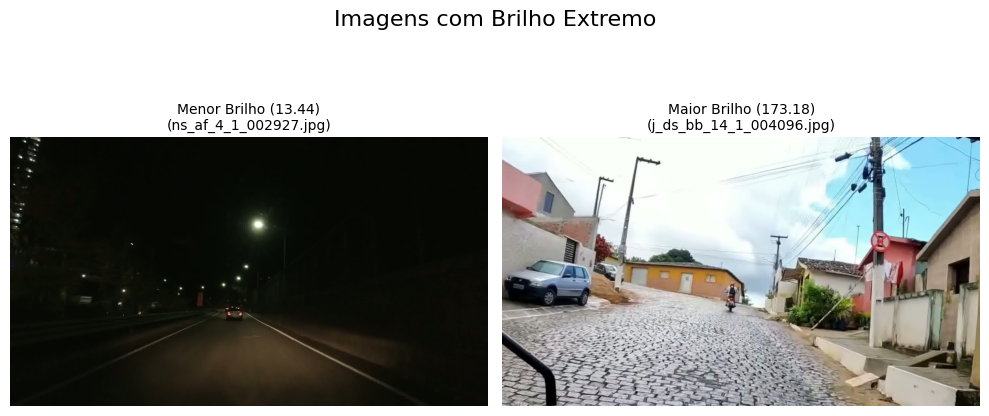

In [ ]:
# Imagens com maior e menor brilho
min_brightness_img_path = metrics_df.loc[metrics_df['brightness'].idxmin()]['path']
max_brightness_img_path = metrics_df.loc[metrics_df['brightness'].idxmax()]['path']

extreme_brightness_paths = [min_brightness_img_path, max_brightness_img_path]

extreme_brightness_titles = [
    f"Menor Brilho ({metrics_df['brightness'].min():.2f})",
    f"Maior Brilho ({metrics_df['brightness'].max():.2f})"
]

plt.figure(figsize=(10, 5))
plt.suptitle('Imagens com Brilho Extremo', fontsize=16)

for i, img_path in enumerate(extreme_brightness_paths):
    plt.subplot(1, 2, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"{extreme_brightness_titles[i]}\n({os.path.basename(img_path)})", fontsize=10)
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### 3.6 Identificação de Outliers por Método Estatístico (IQR)

In [ ]:
# Função para detectar outliers usando o método IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Métricas para verificar outliers
metrics_to_check = ['brightness', 'contrast', 'width', 'height']

all_outlier_images = pd.DataFrame()

print("Detectando outliers nas seguintes métricas usando o método IQR:")
for metric in metrics_to_check:
    outliers_df, lower_bound, upper_bound = detect_outliers_iqr(metrics_df, metric)
    if not outliers_df.empty:
        print(f"  - Métrica '{metric}': {len(outliers_df)} outliers encontrados (Limite Inferior: {lower_bound:.2f}, Limite Superior: {upper_bound:.2f})")
        # Adicionar uma coluna indicando por qual métrica a imagem é um outlier
        outliers_df['outlier_metric'] = metric
        all_outlier_images = pd.concat([all_outlier_images, outliers_df])
    else:
        print(f"  - Métrica '{metric}': Nenhum outlier encontrado.")

# Remover duplicatas, pois uma imagem pode ser outlier em múltiplas métricas
all_outlier_images = all_outlier_images.drop_duplicates(subset=['path']).reset_index(drop=True)

print(f"\nTotal de imagens identificadas como potenciais outliers: {len(all_outlier_images)}")
display(all_outlier_images.head())


Detectando outliers nas seguintes métricas usando o método IQR:
  - Métrica 'brightness': Nenhum outlier encontrado.
  - Métrica 'contrast': Nenhum outlier encontrado.
  - Métrica 'width': 130 outliers encontrados (Limite Inferior: 1920.00, Limite Superior: 1920.00)
  - Métrica 'height': 169 outliers encontrados (Limite Inferior: 945.00, Limite Superior: 1161.00)

Total de imagens identificadas como potenciais outliers: 169


/tmp/ipykernel_1457/3104785555.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['outlier_metric'] = metric
/tmp/ipykernel_1457/3104785555.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['outlier_metric'] = metric


,path,class,brightness,contrast,mean_r,mean_g,mean_b,width,height,outlier_metric
0,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,54.334845,37.777230,60.825597,55.323631,46.855307,1280,576,width
1,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,58.160257,32.778700,62.336034,59.335010,52.809726,1280,576,width
2,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,47.645349,38.406281,53.689802,47.590371,41.655874,1280,576,width
3,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,41.043688,36.032688,48.119093,41.188403,33.823566,1280,576,width
4,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,53.481027,32.081734,60.693922,54.640978,45.108181,1280,576,width


#### 3.7 Visualização de Amostras de Outliers Identificados

Vamos exibir algumas das imagens identificadas como potenciais outliers para uma inspeção visual.

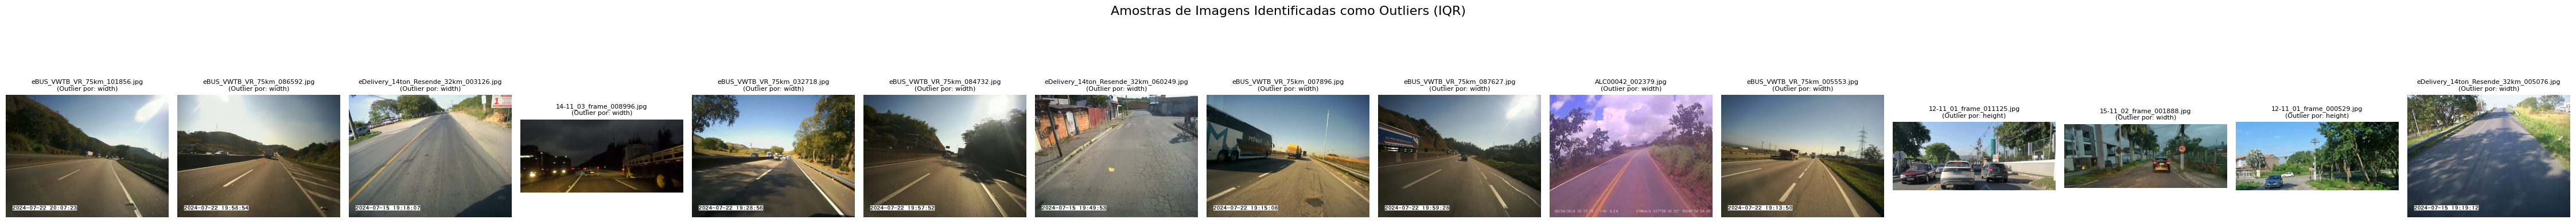

In [ ]:
if not all_outlier_images.empty:
    # Selecionar até 10 imagens aleatórias dos outliers para visualização
    num_samples_to_show = min(15, len(all_outlier_images))
    sample_outlier_paths = random.sample(all_outlier_images['path'].tolist(), num_samples_to_show)

    plt.figure(figsize=(num_samples_to_show * 3, 5))
    plt.suptitle('Amostras de Imagens Identificadas como Outliers (IQR)', fontsize=16)

    for i, img_path in enumerate(sample_outlier_paths):
        plt.subplot(1, num_samples_to_show, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        # Encontrar a métrica que classificou esta imagem como outlier para o título
        outlier_info = all_outlier_images[all_outlier_images['path'] == img_path].iloc[0]
        title_text = f"{os.path.basename(img_path)}\n(Outlier por: {outlier_info['outlier_metric']})"
        plt.title(title_text, fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Nenhuma imagem identificada como outlier pelo método IQR para visualização.")


##Conclusões sobre a EDA

Por meio do EDA feito sobre o dataset, podemos concluir algumas coisas como:


**-** Nosso dataset é dividido em 3 tipos de classes targets(asplhat, offroad e belgian_blocks), sendo as 3 classes distribuídas de forma extremamente desbalanceada, sendo no total 900 features para treino de modo que temos 655 imagens do tipo asphalt(72,8% do dataset), 151 do tipo offroad(16,8% do dataset) e 94 do tipo belgian_blocks (10,4% do dataset) e isso pode ser um grande problema para a continuidade do projeto, visto que um dataset desbalanceado pode gerar overfitting, ou seja, o modelo se ajustaria aos dados do treino e não aprenderia, já que se uma classe representa mais de 70% se o modelo apenas chutar sempre essa classe ele estaria acertando mais que 70% das vezes. Para o tratamento do desbalanceamento estou pensando em duas hipóteses, a primeira se trata de usar oversampling, ou seja isso fará com que as imagens das classes menores apareçam com mais frequência em cada época assim dando uma equilibrada no desbalanceamento. Já minha segunda solução seria atribuir pesos para as classes, dessa forma as classes minoritárias teriam pesos maiores, ou seja, se o modelo erra a classe minoritária ele seria penalizado de maneira mais rígida e dessa forma o modelo vai ser erforça mais para reduzir os erros das classes minoritárias, assim reduzindo a chance do modelo de apenas chutar a classe majoritária.


**-** Foi verificado também que todas as features estão em apensa um único tipo(JPEG), não que isso mude muita coisa, mas so para questão analítica.


**-** Foi feita a análise das dimensões das imagens também para que seja feita posteriormente a normalização das imagens e foi constatado que a maioria das imagens estão na dimensionalidade de 1800x1100 ou proporção de 1.8, com isso temos que tomar cuidado ao mudar a resolução da imagem para não termos perca de informações(farei alguns teste com 384X384, 512x512 e até 600x600), foi informado também as descrição:

Estatísticas de Largura:
 Mínima: 640, Máxima: 1920, Média: 1801.71, Mediana: 1920.0

Estatísticas de Altura:
 Mínima: 480, Máxima: 1080, Média: 1003.13, Mediana: 1080.0

Estatísticas de Proporção (Largura/Altura):
 Mínima: 1.33, Máxima: 2.55, Média: 1.80, Mediana: 1.78



**-** Também foram feitas análises de cores, brilhos e contrastes nas imagens afim de procurar alguns padrões, dessa maneira concluimos que O Brilho é uma Métrica "Mentirosa". A Descoberta: Os gráficos mostram comportamento bimodal, revelando que as estradas asphalt estão bem distribuídas e todos os tipos de brilhos, enquanto a offroad está em brilhos mais altos, o que poderia levar a hipótese que as imagens offroads poderiam ter um padrão de serem tiradas durante o dia, enquanto as asphalts terem fotos de dias e de noite, mas ao ir mais afundo ao visualizar as imagens da offroad(mais de uma vez foram pego aleatoriamente grupos de 5 imagens) vimos que se predominava as fotos de noite, mas o seu brilho é classificado como alto não por causa do sol, mas sim por uma presença de uma luz muito forte(farol) em um fundo escuro(a estrada sem iluminação a noite) demonstrando sim que o brilho é uma métrica mentirosa. Diferente do contastre que é sim uma boa métrica de diferenciação, visto que:

Asphalt (Roxo): Tem uma distribuição de contraste muito larga. Isso acontece porque o asfalto liso tem baixo contraste, mas o asfalto molhado com reflexos gera picos de contraste altíssimos.

Offroad (Laranja): O contraste é mais "comportado" e centralizado.

Belgian Blocks (Rosa): Veja como o pico de contraste dela é ligeiramente deslocado para a direita (~65-70) em comparação ao primeiro pico do asfalto. Isso faz sentido: paralelepípedos têm frestas pretas entre pedras claras, gerando naturalmente mais contraste local do que um asfalto liso.

ou seja cada tipo tem contrastes diferente oq pode talvez ser usado para contribuir na classificação do tipo de solo.


**-** Posteriormente foram feita buscas por outliers e foi usado o metódo dos quartis partindo como paramêtros as métricas de brilho, contraste, largura e altura das imagens e com isso so achamos outliers quando se trata de largura ou altura e essa imagens não são de fato outliers visto que as imagens não estavam em proporções muito fora do padrão, isso ocorreu apenas por termos um dataset bastante homogeneo quando se trata dessas métricas e qualquer coisa que fuja um pouco disso seria classificado como outlier, mesmo sendo uma boa imagem com informações úteis. A tentativa principal da busca dos outliers era ve se o brilho e o contraste podiam contribuir para que deixasse a pista desfocada e sem chance de ser classificada ou com muita dificuldade para classificar até para o olho humano, oq não foi comprovado, mas ao olhar algumas imagens **(como a (07-11-02 (3)_frame_005814.jpg(a imagem de maior altura do dataset)))** ao olho nu verifiquei que é possível que tenhamos outliers no dataset e que o principal responsável disso seriam as condições temporais como chuva, oq não fui capaz de achar uma solução para filtrar as imagens por condição temporal visto que não temos uma coluna "tempo".

**-** Por fim o próximo passe será testar diversos tipos de hipóteses para vê qual obtém o melhor resultado, provavelmente o algoritmo escolhido será uma Convolutional Neural Network(CNN) e testarei com os dados balanceados, os dados não balanceados, treinando uma rede do zero, usando uma rede ja treinada e como no EDA foi visto que o contraste possa ter um papel importante na classificação, a rede neural que tiver o melhor resultado vou testar passando para ela antes da última camada de classificação os valores do contraste da imagem com os dados que vieram da imagem para verificar se teremos um resultado melhor!

##

##Teste com uma CNN pré treinada e sem balanceamento

---



### 1. Configuração do Modelo e Hiperparâmetros

Vamos definir o dispositivo (GPU/CPU), carregar o modelo ResNet18 pré-treinado e ajustar sua camada final para o número de classes do nosso dataset. Também definiremos o otimizador e a função de perda.

In [ ]:
import torch.optim as optim
from torchvision import models

# Definir o dispositivo (GPU se disponível, caso contrário CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Carregar o modelo ResNet18 pré-treinado
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Substituir a camada final (fully connected) para o número de classes do nosso dataset
# O ResNet18 original tem 1000 saídas para ImageNet
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))

# Mover o modelo para o dispositivo selecionado
model = model.to(device)

# Definir a função de perda e o otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Hiperparâmetros de treinamento
num_epochs = 10


Usando dispositivo: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


### 2. Função de Treinamento

Esta função irá lidar com o loop de treinamento para cada época, calculando a perda e a acurácia no conjunto de treino.

In [ ]:
def train_model(model, criterion, optimizer, train_loader, device):
    model.train() # Coloca o modelo em modo de treinamento
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in tqdm(train_loader, desc="Treinando"): # Use tqdm para barra de progresso
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zera os gradientes do otimizador

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Calcula os gradientes descendente
        optimizer.step() # Atualiza os pesos do modelo

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_predictions / total_predictions
    return epoch_loss, epoch_acc

### 3. Função de Avaliação

Esta função irá avaliar o desempenho do modelo no conjunto de teste, calculando a perda e a acurácia sem atualizar os pesos do modelo.

In [ ]:
def evaluate_model(model, criterion, test_loader, device):
    model.eval() # Coloca o modelo em modo de avaliação (desativa dropout e batch norm)
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    all_labels = [] # Lista para armazenar todos os rótulos verdadeiros
    all_predictions = [] # Lista para armazenar todas as previsões do modelo

    with torch.no_grad(): # Desativa o cálculo de gradientes para economia de memória e velocidade
        for inputs, labels in tqdm(test_loader, desc="Avaliando"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / len(test_loader.dataset)
    epoch_acc = correct_predictions / total_predictions
    return epoch_loss, epoch_acc, all_labels, all_predictions # Retorna as listas de rótulos e previsões

### 4. Loop Principal de Treinamento e Avaliação

Agora vamos rodar o treinamento por um número definido de épocas e acompanhar o desempenho.

In [ ]:
train_losses_total = []
train_accuracies_total = []
test_losses_total = []
test_accuracies_total = []

#Foi criado o loop de range 30 para termos noção do real aproveiamento do modelo
#Visto que redes neurais são modelos estocásticos ou não determinístico, ou seja,
#A cada rodada o resultado pode mudar(isso serve para dar mais credibilidade ao resultado)
for i in range(15):
  print(f"Treino: {i+1}/15")
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []
  for epoch in range(num_epochs):
      print(f"\nEpoch {epoch+1}/{num_epochs}")

      # Treinar o modelo
      train_loss, train_acc = train_model(model, criterion, optimizer, train_loader, device)
      train_losses.append(train_loss)
      train_accuracies.append(train_acc)
      print(f"  Treino -> Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")

      # Avaliar o modelo
      test_loss, test_acc, _, _ = evaluate_model(model, criterion, test_loader, device) # Agora desempacota os 4 valores
      test_losses.append(test_loss)
      test_accuracies.append(test_acc)
      print(f"  Teste  -> Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

  print("\nTreinamento concluído!")
  train_losses_total = train_losses_total + train_losses
  train_accuracies_total = train_accuracies + train_accuracies
  test_losses_total = test_losses_total + test_losses
  test_accuracies_total = test_accuracies_total + test_accuracies


### 5. Visualização do Histórico de Treinamento

Vamos plotar as curvas de perda e acurácia ao longo das épocas para analisar o progresso do treinamento.

NameError: name 'num_epochs' is not defined

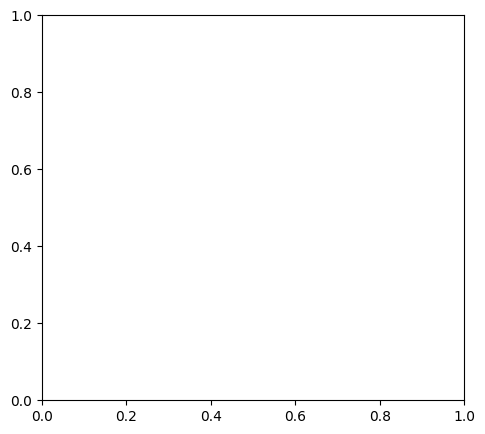

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Treino Loss')
plt.plot(range(1, num_epochs + 1), test_losses, label='Teste Loss')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Treino Acc')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Teste Acc')
plt.title('Curva de Acurácia (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Para a matriz de confusão do modelo final, avaliamos o modelo uma última vez para coletar todos os rótulos e previsões.
_, _, true_labels_final, predicted_labels_final = evaluate_model(model, criterion, test_loader, device)

# Gerar a matriz de confusão
conf_matrix = metrics.confusion_matrix(true_labels_final, predicted_labels_final)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names) # Usar class_names para os rótulos
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão do Modelo Final')
plt.show()

# Imprimir o relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(true_labels_final, predicted_labels_final, target_names=class_names))

###5.1 Criando uma tabela para guadar os resultados dos testes

In [ ]:
import json

# Gerar o relatório de classificação como um dicionário
classification_rep_dict = classification_report(true_labels_final, predicted_labels_final, target_names=class_names, output_dict=True)

# Extrair as métricas de interesse do relatório
summary_classification_metrics = {
    'accuracy': classification_rep_dict['accuracy'],
    'macro_avg_precision': classification_rep_dict['macro avg']['precision'],
    'macro_avg_recall': classification_rep_dict['macro avg']['recall'],
    'macro_avg_f1_score': classification_rep_dict['macro avg']['f1-score'],
    'weighted_avg_precision': classification_rep_dict['weighted avg']['precision'],
    'weighted_avg_recall': classification_rep_dict['weighted avg']['recall'],
    'weighted_avg_f1_score': classification_rep_dict['weighted avg']['f1-score']
}

# Criar o dicionário para guardar os resultados e parâmetros
results_data = {
    'parameters': {
        'num_epochs': num_epochs,
        'batch_size': batch_size,
        'learning_rate': optimizer.param_groups[0]['lr'],
        'loss_function': str(criterion.__class__.__name__),
    },
    'training_history': {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'test_losses': test_losses,
        'test_accuracies': test_accuracies
    },
    'final_metrics': {
        'confusion_matrix': conf_matrix.tolist(), # Converte numpy array list para JSON
        'classification_summary': summary_classification_metrics, # Use the summary metrics here
        'class_names': class_names
    }
}

print("Dicionário de resultados e parâmetros criado com sucesso!")

In [ ]:
def flatten_dict(d, parent_key='', sep='_'):
    """Flattens a nested dictionary."""
    items = []
    for k, v in d.items():
        new_key = parent_key + sep + k if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            if new_key in ['training_history_train_losses', 'training_history_train_accuracies',
                          'training_history_test_losses', 'training_history_test_accuracies']:
                items.append((new_key, [f"{x:.4f}" for x in v]))
            else:
                items.append((new_key, v))
        else:
            items.append((new_key, v))
    return dict(items)

# Achata os resultados em um dicionario de dados
flattened_results = flatten_dict(results_data)

# Cria um DataFrame do a partir do dicionário
df_results_summary = pd.DataFrame([flattened_results])

# Mapeamento de nomes de colunas para exibição amigável
column_display_names = {
    'parameters_learning_rate': 'Learning Rate',
    'parameters_num_epochs': 'Epochs',
    'parameters_batch_size': 'Batch Size',
    'parameters_loss_function': 'Loss Function',
    'final_metrics_confusion_matrix': 'Confusion Matrix',
    'final_metrics_classification_summary_accuracy': 'Accuracy',
    'final_metrics_classification_summary_macro_avg_precision': 'Macro Avg Precision',
    'final_metrics_classification_summary_macro_avg_recall': 'Macro Avg Recall',
    'final_metrics_classification_summary_macro_avg_f1_score': 'Macro Avg F1-Score',
    'final_metrics_classification_summary_weighted_avg_precision': 'Weighted Avg Precision',
    'final_metrics_classification_summary_weighted_avg_f1_score': 'Weighted Avg F1-Score',
    'final_metrics_classification_summary_weighted_avg_recall': 'Weighted Avg Recall'
}

# Seleciona apenas as colunas desejadas e as renomeia em uma única operação
selected_and_renamed_df = df_results_summary[list(column_display_names.keys())].rename(columns=column_display_names)

# Define as colunas que devem ser formatadas como float com 2 casas decimais (usando os nomes amigáveis)
metrics_to_format = [
    'Accuracy',
    'Macro Avg Precision',
    'Macro Avg Recall',
    'Macro Avg F1-Score',
    'Weighted Avg Precision',
    'Weighted Avg Recall',
    'Weighted Avg F1-Score',
    'Learning Rate'
]

print("Visualização tabular dos resultados e parâmetros do treinamento:")
display(selected_and_renamed_df.style.format({col: '{:.2f}'if col !="Learning Rate" else '{:.3f}' for col in metrics_to_format if col != 'Confusion Matrix'})) # Excluindo 'Confusion Matrix' da formatação numérica

##Teste com uma CNN do zero e sem balanceamento

---



### 1. Definir a Arquitetura da CNN do Zero

Vamos criar uma arquitetura de CNN simples para classificação de imagens. Esta rede incluirá camadas convolucionais, de pooling e totalmente conectadas.

In [ ]:
import torch.nn.functional as F

# Definição da arquitetura da CNN do zero
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 canais de entrada (RGB), 32 filtros, kernel 3x3
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2) # Camada de pooling 2x2

        # Para calcular a dimensão da entrada para a camada linear, precisamos simular
        # o forward pass com uma imagem de exemplo após as camadas convolucionais.
        # Considerando `transforms.Resize((384, 384))`:
        # Após 3 pools de 2x2, a dimensão espacial será 384 / (2*2*2) = 384 / 8 = 48.
        # Então, a entrada para a camada linear será 128 * 48 * 48.
        self.fc1 = nn.Linear(128 * 48 * 48, 512) # Camada totalmente conectada
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flattening
        x = x.view(-1, 128 * 48 * 48) # Ajusta conforme as dimensões calculadas
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("Definição da classe SimpleCNN concluída.")

### 2. Configurar o Modelo, Otimizador e Hiperparâmetros

Vamos instanciar a nossa `SimpleCNN` e definir o otimizador e a função de perda.

In [ ]:
# Resetar o modelo para a nova arquitetura
model_scratch = SimpleCNN(num_classes=len(train_dataset.classes))
model_scratch = model_scratch.to(device)

# Redefinir otimizador e critério para o novo modelo
criterion_scratch = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

# Hiperparâmetros de treinamento (reutilizar num_epochs)
# num_epochs = 10 # Já definido anteriormente

print(f"Modelo SimpleCNN instanciado e movido para {device}.")

### 3. Loop Principal de Treinamento e Avaliação (CNN do Zero)

Agora vamos treinar e avaliar a nossa `SimpleCNN`.

In [ ]:
train_losses_scratch_total = []
train_accuracies_scratch_total = []
test_losses_scratch_total = []
test_accuracies_scratch_total = []

for i in range(15):
  print(f"Treino: {i+1}/15")

  train_losses_scratch = []
  train_accuracies_scratch = []
  test_losses_scratch = []
  test_accuracies_scratch = []

  # Loop de treinamento e avaliação
  for epoch in range(num_epochs):
      print(f"\nEpoch {epoch+1}/{num_epochs} (CNN do Zero)")

      # Treinar o modelo
      train_loss, train_acc = train_model(model_scratch, criterion_scratch, optimizer_scratch, train_loader, device)
      train_losses_scratch.append(train_loss)
      train_accuracies_scratch.append(train_acc)
      print(f"  Treino (CNN do Zero) -> Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")

      # Avaliar o modelo
      test_loss, test_acc, _, _ = evaluate_model(model_scratch, criterion_scratch, test_loader, device)
      test_losses_scratch.append(test_loss)
      test_accuracies_scratch.append(test_acc)
      print(f"  Teste (CNN do Zero)  -> Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

      train_losses_scratch_total = train_losses_scratch_total +train_losses_scratch
      train_accuracies_scratch_total = train_accuracies_scratch_total + train_accuracies_scratch
      test_losses_scratch_total = test_losses_scratch_total + test_losses_scratch
      test_accuracies_scratch_total = test_accuracies_scratch_total + test_accuracies_scratch

  print("\nTreinamento da CNN do Zero concluído!")

### 4. Visualização do Histórico de Treinamento (CNN do Zero)

Vamos plotar as curvas de perda e acurácia para a CNN treinada do zero.

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses_scratch, label='Treino Loss (CNN do Zero)')
plt.plot(range(1, num_epochs + 1), test_losses_scratch, label='Teste Loss (CNN do Zero)')
plt.title('Curva de Perda (Loss) - CNN do Zero')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies_scratch, label='Treino Acc (CNN do Zero)')
plt.plot(range(1, num_epochs + 1), test_accuracies_scratch, label='Teste Acc (CNN do Zero)')
plt.title('Curva de Acurácia (Accuracy) - CNN do Zero')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

### 5. Matriz de Confusão e Relatório de Classificação (CNN do Zero)

Vamos analisar o desempenho final da CNN treinada do zero no conjunto de teste.

In [ ]:
# Para a matriz de confusão do modelo final, avaliamos o modelo uma última vez.
_, _, true_labels_final_scratch, predicted_labels_final_scratch = evaluate_model(model_scratch, criterion_scratch, test_loader, device)

# Gerar a matriz de confusão
conf_matrix_scratch = metrics.confusion_matrix(true_labels_final_scratch, predicted_labels_final_scratch)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_scratch, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names) # Usar class_names para os rótulos
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão do Modelo Final (CNN do Zero)')
plt.show()

# Imprimir o relatório de classificação
print("\nRelatório de Classificação (CNN do Zero):")
print(classification_report(true_labels_final_scratch, predicted_labels_final_scratch, target_names=class_names))

### 6. Criando uma tabela para guardar os resultados do teste (CNN do Zero)

In [ ]:
# Gerar o relatório de classificação como um dicionário
classification_rep_dict_scratch = classification_report(true_labels_final_scratch, predicted_labels_final_scratch, target_names=class_names, output_dict=True)

# Extrair as métricas de interesse do relatório
summary_classification_metrics_scratch = {
    'accuracy': classification_rep_dict_scratch['accuracy'],
    'macro_avg_precision': classification_rep_dict_scratch['macro avg']['precision'],
    'macro_avg_recall': classification_rep_dict_scratch['macro avg']['recall'],
    'macro_avg_f1_score': classification_rep_dict_scratch['macro avg']['f1-score'],
    'weighted_avg_precision': classification_rep_dict_scratch['weighted avg']['precision'],
    'weighted_avg_recall': classification_rep_dict_scratch['weighted avg']['recall'],
    'weighted_avg_f1_score': classification_rep_dict_scratch['weighted avg']['f1-score']
}

# Criar o dicionário para guardar os resultados e parâmetros
results_data_scratch = {
    'parameters': {
        'num_epochs': num_epochs,
        'batch_size': batch_size,
        'learning_rate': optimizer_scratch.param_groups[0]['lr'],
        'loss_function': str(criterion_scratch.__class__.__name__),
        'model_architecture': 'SimpleCNN_from_scratch'
    },
    'training_history': {
        'train_losses': train_losses_scratch,
        'train_accuracies': train_accuracies_scratch,
        'test_losses': test_losses_scratch,
        'test_accuracies': test_accuracies_scratch
    },
    'final_metrics': {
        'confusion_matrix': conf_matrix_scratch.tolist(), # Converte numpy array list para JSON
        'classification_summary': summary_classification_metrics_scratch, # Use the summary metrics here
        'class_names': class_names
    }
}

print("Dicionário de resultados e parâmetros para CNN do Zero criado com sucesso!")

# Achata os resultados em um dicionario de dados
flattened_results_scratch = flatten_dict(results_data_scratch)

# Cria um DataFrame do a partir do dicionário
df_results_summary_scratch = pd.DataFrame([flattened_results_scratch])

# Mapeamento de nomes de colunas para exibição amigável (reutilizando o anterior e adicionando o modelo)
column_display_names_scratch = column_display_names.copy()
column_display_names_scratch['parameters_model_architecture'] = 'Model Architecture'

# Seleciona apenas as colunas desejadas e as renomeia em uma única operação
selected_and_renamed_df_scratch = df_results_summary_scratch[list(column_display_names_scratch.keys())].rename(columns=column_display_names_scratch)

print("Visualização tabular dos resultados e parâmetros do treinamento (CNN do Zero):")
display(selected_and_renamed_df_scratch.style.format({col: '{:.2f}'if col !="Learning Rate" else '{:.3f}' for col in metrics_to_format if col != 'Confusion Matrix'}))
